In [1]:
%matplotlib widget
import numpy as np
import json, glob, copy
import os, math
#import pandas as pd
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output, display
from datetime import datetime

from alvra_tools.load_data import *
from alvra_tools.channels import *
from alvra_tools.timing_tool import *
from alvra_tools.utils import *
from alvra_tools.YAG_scans import *
from ipyfilechooser import FileChooser

import warnings
warnings.filterwarnings('ignore')

In [39]:
pgroup='p22829'
runnumber = 79
print ('run: {:04d}'.format(runnumber))

#############################################################
jsonfile = ''
jsonfile = glob.glob('/sf/alvra/data/{}/raw/*{:04d}*/meta/scan.json'.format(pgroup, runnumber))[0]
titlestring = str( pgroup + ' --- ' +jsonfile.split('/')[-3])
jsonfile

run: 0079


'/sf/alvra/data/p22829/raw/run0079-t0_scan_prepulse/meta/scan.json'

In [40]:
detector_Izero = channel_Izero122
quantile = 0.7

reducedir= '/sf/alvra/data/{}/work/Reduced_data/Reduced_YAG/'.format(pgroup)
saveflag = True
Delay_fs, Pump_probe_all, Pump_probe_avg, Pump_probe_avg_err = YAG_scanPP_noTT(reducedir, saveflag, detector_Izero, jsonfile, quantile)

Processing: /sf/alvra/data/p22829/raw/run0079-t0_scan_prepulse/meta/scan.json
Step 21 of 21: Processing acq0021

--------------------------------------------------------------------------------

SAR-CVME-TIFALL4:EvtSet       501 / 501 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SAROP11-GES1:PR1_CH1_VAL_GET  501 / 501 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SAROP11-PBPS122:INTENSITY     501 / 501 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SLAAR11-LSCP1-FNS:CH2:VAL_GET 501 / 501 -> 0% loss ▇▇▇▇▇▇▇▇▇▇

over the whole data set: 501 / 501 -> 0% loss
complete channels: 4 / 4 -> 0% incomplete

--------------------------------------------------------------------------------

FEL rep rate is 100.0 Hz
Laser rep rate is 50.0 Hz (delayed or dark)
Pump scheme is 1:1
Loaded 248 pump and 248 unpump shots
------------------------------
Processed 21 out of 21 files


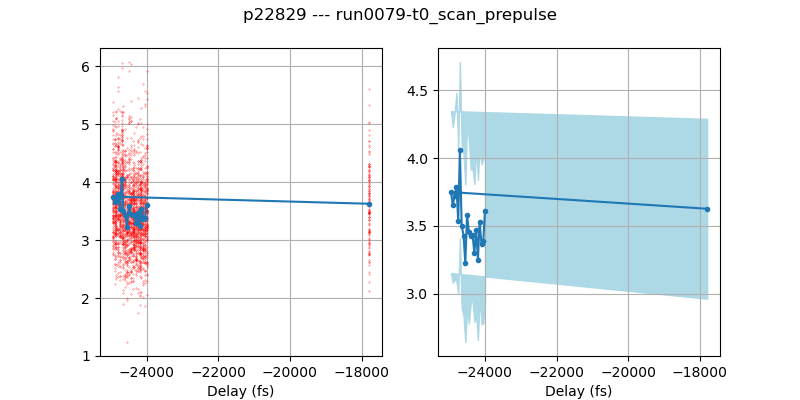

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle(titlestring)
pp = Pump_probe_avg
err_pp_low = pp-Pump_probe_avg_err
err_pp_high = pp+Pump_probe_avg_err

from sfdata import SFScanInfo
scan = SFScanInfo(jsonfile)
units = scan.parameters['units'][0]

for i in range(len(Delay_fs)):
    xe = Delay_fs[i]
    ye =Pump_probe_all[i]
    ax1.plot([xe] * len(ye), ye, 'r.', ms=.5, alpha=0.8)
ax1.plot(Delay_fs, pp, label='shot-to-shot, filter {}'.format(quantile), marker='.')
ax1.set_xlabel("Delay ({})".format(units))
#ax1.legend(loc="best")
ax1.grid()

ax2.plot(Delay_fs, pp, label='shot-to-shot, {}%'.format(quantile*100), marker='.')
ax2.fill_between(np.squeeze(Delay_fs), err_pp_low, err_pp_high, color='lightblue')
ax2.set_xlabel("Delay ({})".format(units))
ax2.grid()

plt.show()
fig.tight_layout()



## Choose fit function

In [7]:
# err function ---------------> [x0, amplitude, width, offset]
# exp_gauss_heaviside --------> [x0, amplitude, width, offset, lifetime]
# conv_exp_gauss_heaviside2 --> [x0, amplitude, width, offset, lifetime, a, b]

fit = Fit(errfunc_fwhm, estimate_errfunc_parameters)
#fit = Fit(conv_exp_gauss_heaviside, estimate_conv_exp_gauss_heaviside_parameters) 
#fit = Fit(conv_exp_gauss_heaviside2, estimate_conv_exp_gauss_heaviside2_parameters)

## Do the fit

In [8]:
fit.estimate(Delay_fs, pp)            # this sets some internal params 
#fit.p0 = better_p0(fit.p0, 4,200)# overwrite some values (index) if needed: 
#fit.p0 = better_p0(fit.p0, 0, 210.42) # overwrite some values (index) if needed: 
#fit.p0 = better_p0(fit.p0, 4, 250) # overwrite some values (index) if needed: 

fit.fit(Delay_fs,pp,maxfev=200000)                  # calculate the fit
pp_fit = fit.eval(Delay_fs)           # evaluate the curve for plotting

t0_fs = fit.popt[0]
width_fs = fit.popt[2]
width_mm = fs2mm(width_fs,0)

print("Position t0 = {:.4f} {}".format(t0_fs, units))
print("Width = {:.4f} {}".format(width_fs, units))

Position t0 = 10.1234 fs
Width = 139.4796 fs


## Plot the fit

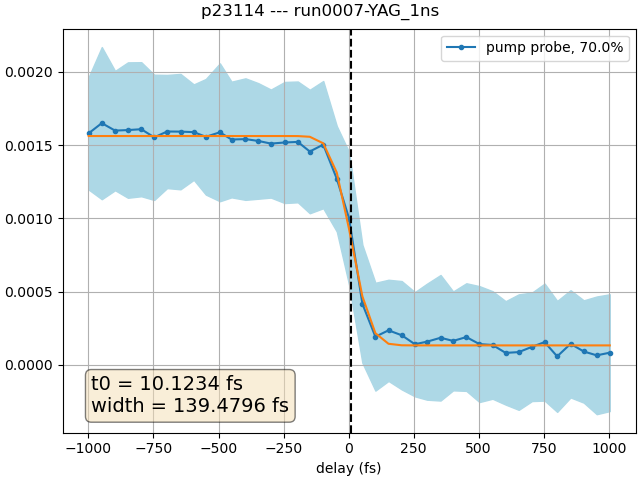

Returned t0 from fit = 10.123421 fs 


In [9]:
#Delay_fs = mm2fs(Delay_mm,t0_mm)

fig, ax = plt.subplots(constrained_layout=True)
#fig, ax = plt.subplots()
plt.suptitle(titlestring)

plt.plot(Delay_fs, pp, label='pump probe, {}%'.format(quantile*100),marker='.')
plt.fill_between(Delay_fs, err_pp_low, err_pp_high, color='lightblue')

plt.plot(Delay_fs, pp_fit)

plt.grid()
plt.xlabel("delay ({})".format(units))
plt.legend(loc="best")


boxstyle = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
boxtext = '\n'.join((r't0 = {:.4f} fs'.format(t0_fs),
                   r'width = {:.4f} fs'.format(np.abs(width_fs))))
plt.text(0.05, 0.05, boxtext, transform=ax.transAxes, bbox=boxstyle, fontsize=14)
plt.axvline(x = t0_fs, color = 'k', linestyle = '--')

plt.show()
print ('Returned t0 from fit = {:.6f} {} '.format(t0_fs, units))

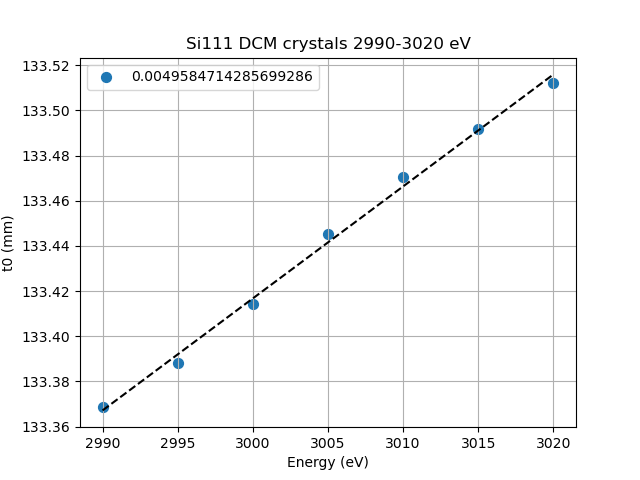

slope (mm/eV) = 0.0049584714285699286


In [72]:
energy=np.array([2990, 2995, 3000, 3005, 3010, 3015, 3020 ])
t0= np.array([133.36859, 133.38836, 133.41411, 133.445489, 133.470470, 133.491765,133.512262  ])

#t0_fs= np.array([(t0-113.4531)*2/(3335.64)])
#print(t0_fs)
#plt.figure(figsize = (8,4))
#plt.plot(energy, t0_fs, label='Mono Calibration 2460-2490 eV',marker='o')
#plt.show5



m,b = np.polyfit(energy,t0, 1) 

plt.figure()
plt.title('Si111 DCM crystals 2990-3020 eV')

plt.plot (energy, m*energy + b,  '--', color='black')
plt.scatter(energy, t0, s = 200, marker='.',label = str(m))
plt.legend(loc='best')
plt.xlabel('Energy (eV)')
plt.ylabel('t0 (mm)')
plt.grid()
plt.show()

print('slope (mm/eV) = {}'.format(m))

In [10]:
runlist = np.arange(18, 25, 1)
#runlist = [57,77]
Loaddir = '/sf/alvra/data/p20845/raw/'
##############################################
print ('Will load {} runs: {} from {}'.format(len(runlist), runlist, Loaddir))

Will load 7 runs: [18 19 20 21 22 23 24] from /sf/alvra/data/p20845/raw/


In [11]:
from itertools import chain
datafiles = []
print (runlist)
for run in runlist:
    file = glob.glob(Loaddir + '*{:04d}*/meta/scan.json'.format(run))
    datafiles.append(file)
datafiles = itertools.chain.from_iterable(datafiles)
datafiles = sorted(datafiles, key = os.path.getmtime)
print ('{} files found'.format(len(datafiles)))
datafiles    

[18 19 20 21 22 23 24]
7 files found


['/sf/alvra/data/p20845/raw/run0018-YAG_timing_2990eV/meta/scan.json',
 '/sf/alvra/data/p20845/raw/run0019-YAG_timing_2995eV/meta/scan.json',
 '/sf/alvra/data/p20845/raw/run0020-YAG_timing_3000eV/meta/scan.json',
 '/sf/alvra/data/p20845/raw/run0021-YAG_timing_3005eV/meta/scan.json',
 '/sf/alvra/data/p20845/raw/run0022-YAG_timing_3010eV/meta/scan.json',
 '/sf/alvra/data/p20845/raw/run0023-YAG_timing_3015eV/meta/scan.json',
 '/sf/alvra/data/p20845/raw/run0024-YAG_timing_3020eV/meta/scan.json']

# Loop over several runs

In [12]:
quantile_band = 0.5

Timezero_start = 133.36859

########################################################################
from sfdata import SFScanInfo

t0_fs_scan =[]
width_fs_scan = []

for json_file in datafiles:
    print (json_file)
    scan = SFScanInfo(json_file)
    scan = remove_JF_from_scan(scan)
    
    Delay_mm,Delay_fs,Pump_probe,_,_,_,_ = YAG_scan_noTT(scan,quantile_band)
        
    pp = Pump_probe[:,0]
    
    fit = Fit(errfunc_fwhm, estimate_errfunc_parameters)
    # fit = Fit(conv_exp_gauss_heaviside, estimate_conv_exp_gauss_heaviside_parameters) 
    # fit = Fit(conv_exp_gauss_heaviside2, estimate_conv_exp_gauss_heaviside2_parameters)
    
    fit.estimate(Delay_mm, pp)      # this sets some internal params 
           
    #fit.p0 = better_p0(fit.p0, 0, Timezero_start)  # overwrite some values if needed

    fit.fit(Delay_mm,pp)            # calculate the fit
    pp_fit = fit.eval(Delay_mm)     # evaluate the curve for plotting
    
    t0_mm = fit.popt[0]
    width_mm = fit.popt[2]    
    
    t0_fs_scan.append(mm2fs(t0_mm,Timezero_start))
    width_fs_scan.append(mm2fs(width_mm,0))


Processing: run0024-YAG_timing_3020eV
Step 31 of 31: Processing acq0031

--------------------------------------------------------------------------------

SAR-CVME-TIFALL4:EvtSet       501 / 501 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SLAAR11-LSCP1-FNS:CH0:VAL_GET 501 / 501 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SLAAR11-LSCP1-FNS:CH2:VAL_GET 501 / 501 -> 0% loss ▇▇▇▇▇▇▇▇▇▇

over the whole data set: 501 / 501 -> 0% loss
complete channels: 3 / 3 -> 0% incomplete

--------------------------------------------------------------------------------

FEL rep rate is 100.0 Hz
Laser rep rate is 50.0 Hz (delayed or dark)
Pump scheme is 1:1
Loaded 250 pump and 250 unpump shots
Quantile range = 0.25 0.75
Loaded 31 files, size of the arrays = 31
Shape of pump probe data is (31, 250)


[-3.62574226e-04  1.62862011e+00 -1.80030011e+03]


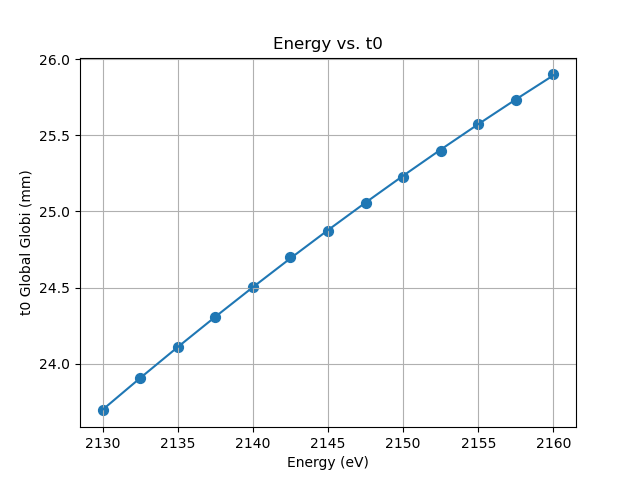

In [137]:
energy=np.array([2130, 2132.5, 2135, 2137.5, 2140, 2142.5, 2145, 2147.5, 2150, 2152.5, 2155.0, 2157.5, 2160])
t0= np.array([23.6935, 23.90405, 24.11217, 24.30815, 24.50657, 24.70143, 24.87341, 25.05511, 25.22784, 25.39941, 25.57515, 25.73212, 25.89902])

plt.figure()
plt.title('Energy vs. t0')

fitting = np.polyfit(energy, t0, 2)
print(fitting)
calib = np.poly1d(np.polyfit(energy, t0, 2))
fit = calib(energy)

plt.scatter(energy, t0, s = 200, marker='.')
plt.plot(energy, fit)
plt.xlabel('Energy (eV)')
plt.ylabel('t0 Global Globi (mm)')
plt.grid()
plt.show()


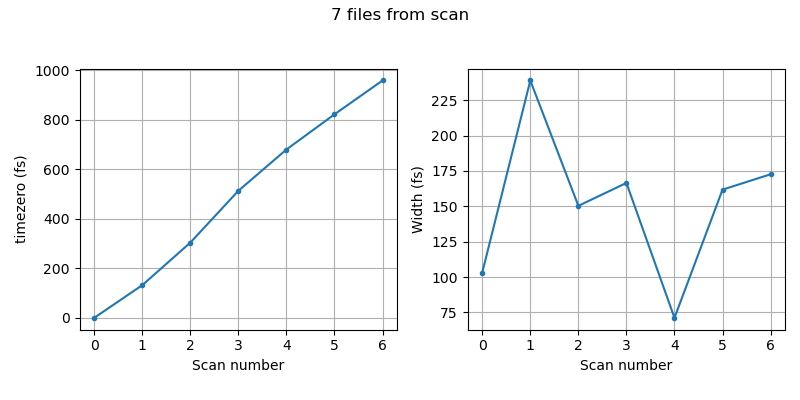

In [15]:
plt.figure(figsize = (8,4))
plt.suptitle ('{} files from {}'.format(len(datafiles), json_file.split('/')[-1].split('.')[0]))

plt.subplot(121)
plt.plot(t0_fs_scan, marker='.')
plt.xlabel('Scan number')
plt.ylabel('timezero (fs)')
plt.grid()

plt.subplot(122)
plt.plot(width_fs_scan, marker='.')
plt.xlabel("Scan number")
plt.ylabel('Width (fs)')
plt.grid()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

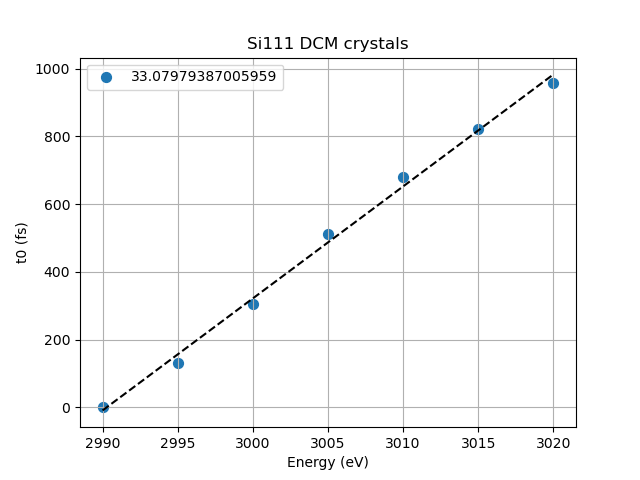

slope (fs/eV) = 33.07979387005959


In [16]:
m,b = np.polyfit(Energy_eV,t0_fs_scan, 1) 

plt.figure()
plt.title('Si111 DCM crystals')

plt.plot (Energy_eV, m*Energy_eV + b,  '--', color='black')
plt.scatter(Energy_eV, t0_fs_scan, s = 200, marker='.',label = str(m))
plt.legend(loc='best')
plt.xlabel('Energy (eV)')
plt.ylabel('t0 (fs)')
plt.grid()
plt.show()

print('slope (fs/eV) = {}'.format(m))

In [55]:
890000-884000

6000

## 2D scan for mono calibration

In [53]:
pgroup='p20845'
runnumber = 25
print ('run: {:04d}'.format(runnumber))

#############################################################
jsonfile = ''
jsonfile = glob.glob('/sf/alvra/data/{}/raw/*{:04d}*/meta/scan.json'.format(pgroup, runnumber))[0]
jsonfile

run: 0025


'/sf/alvra/data/p20845/raw/run0025-mono_calibration_2810-3020/meta/scan.json'

In [54]:
quantile = 0.5

channel_list_pp = [channel_Events, channel_LaserDiode, channel_Laser_refDiode]
channel_list_all = channel_list_pp


###################################################################3
from sfdata import SFScanInfo
scan = SFScanInfo(jsonfile)
scan = remove_JF_from_scan(scan)

Delay_mm = np.asarray(scan.readbacks[:,1])
Energy = np.asarray(scan.readbacks[:,0])
Delay_fs = mm2fs(Delay_mm,0)

Pump_probe_all = []
Pump_probe = []
Pump_probe_avg =[]

for i, step in enumerate(scan):
    check_files_and_data(step)
    clear_output(wait=True)
    filename = scan.files[i][0].split('/')[-1].split('.')[0]
    print ('Processing: {}'.format(scan.fname.split('/')[-3]))
    print ('Step {} of {}: Processing {}'.format(i+1, len(scan.files), filename))
    resultsPP, results_FEL, pids_pump, pids_unpump = load_data_compact_pump_probe(channel_list_pp, channel_list_all, step)

    Laser_pump = resultsPP[channel_LaserDiode].pump
    Laser_ref_pump = resultsPP[channel_Laser_refDiode].pump
    Laser_unpump = resultsPP[channel_LaserDiode].unpump
    Laser_ref_unpump = resultsPP[channel_Laser_refDiode].unpump

    Laser_diff = -np.log10((Laser_pump) / (Laser_unpump))

    Pump_probe_all.append(Laser_diff)
    df_pump_probe = pd.DataFrame(Laser_diff)
    Pump_probe.append(np.nanquantile(df_pump_probe, [0.5, 0.5 - quantile/2, 0.5 + quantile/2]))

    Pump = np.median(Laser_pump)
    Unpump = np.median(Laser_unpump)
    Pump_probe_avg.append(-np.log10((Pump) / (Unpump)))
    
run_name = jsonfile.split('/')[-3]
os.makedirs(reducedir+run_name, exist_ok=True)



Processing: run0025-mono_calibration_2810-3020
Step 4 of 5332: Processing acq0004

--------------------------------------------------------------------------------

SAR-CVME-TIFALL4:EvtSet       501 / 501 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SLAAR11-LSCP1-FNS:CH0:VAL_GET 501 / 501 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SLAAR11-LSCP1-FNS:CH2:VAL_GET 501 / 501 -> 0% loss ▇▇▇▇▇▇▇▇▇▇

over the whole data set: 501 / 501 -> 0% loss
complete channels: 3 / 3 -> 0% incomplete

--------------------------------------------------------------------------------

FEL rep rate is 100.0 Hz
Laser rep rate is 50.0 Hz (delayed or dark)
Pump scheme is 1:1
Loaded 250 pump and 250 unpump shots


KeyboardInterrupt: 

In [83]:
run_array = {}
run_array[run_name.split('-')[0]] = {"name": run_name,
                                "Delay_mm": Delay_mm,
                                "Delay_fs": Delay_fs,
                                "Pump_probe": Pump_probe,
                                "Pump_probe_all": Pump_probe_all,
                                "Pump_probe_avg": Pump_probe_avg}

np.save(reducedir+run_name+'/run_array', run_array)

In [84]:
pp = Pump_probe[:,0]
energy_axis = np.reshape(Energy, (43,124))
delay_axis = np.reshape(Delay_fs, (43, 124))
pp_2D = np.reshape(pp, (43, 124))

In [92]:
t0_mono=[]
width_mono=[]
for index in range(len(pp_2D)):
    fit.estimate(delay_axis[0,:], pp_2D[index,:])            # this sets some internal params 
    fit.fit(delay_axis[0,:],pp_2D[index,:])                  # calculate the fit
    pp_fit = fit.eval(delay_axis[0,:])           # evaluate the curve for plotting

    t0_mono.append(fit.popt[0])
    width_mono.append(fit.popt[2])

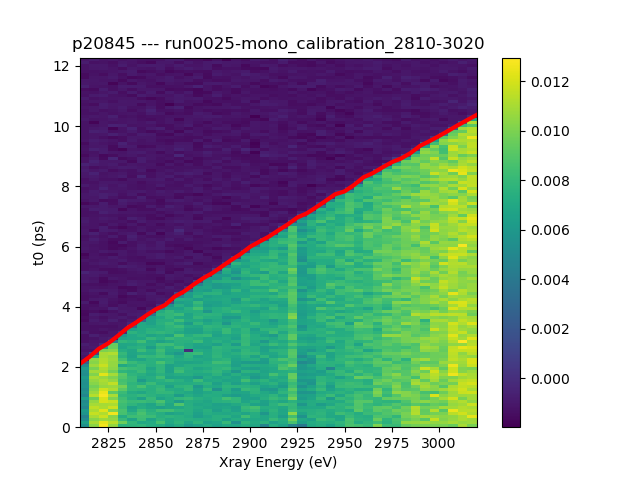

In [99]:
plt.figure()
plt.title(pgroup+ ' --- '+ jsonfile.split('/')[-3])
plt.pcolormesh(energy_axis[:,0],(delay_axis[0,:]-delay_axis[0,0])/1000, pp_2D.T)
plt.plot(energy_axis[:,0], (t0_mono-delay_axis[0,0])/1000, color ='r', linewidth=3)
plt.xlabel('Xray Energy (eV)')
plt.ylabel('t0 (ps)')
plt.colorbar()
plt.show()

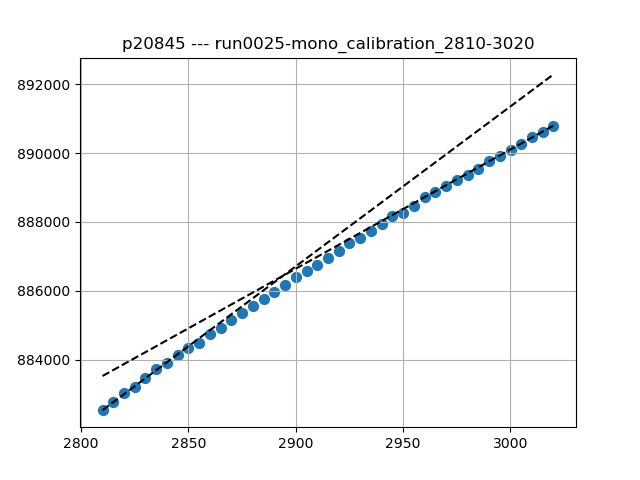

Cl K edge: slope (fs/eV) = 34.618914955309634
Rh L edge: slope (fs/eV) = 46.42981830280732


In [111]:
m_Cl,b_Cl = np.polyfit(energy_axis[-7:,0],t0_mono[-7:], 1) 
m_Rh,b_Rh = np.polyfit(energy_axis[:7,0],t0_mono[:7], 1) 

plt.figure()
plt.title(pgroup+ ' --- '+ jsonfile.split('/')[-3])
plt.plot (energy_axis[:,0], m_Cl*energy_axis[:,0] + b_Cl,  '--', color='black')
plt.plot (energy_axis[:,0], m_Rh*energy_axis[:,0] + b_Rh,  '--', color='black')
plt.scatter(energy_axis[:,0], t0_mono, s = 200, marker='.',label = str(m))
plt.grid()
plt.show()
print('Cl K edge: slope (fs/eV) = {}'.format(m_Cl))
print('Rh L edge: slope (fs/eV) = {}'.format(m_Rh))

In [19]:
offset_space = 19.93699999999876     # this is in um

offset_time = 2*(offset_space * 1e-6)/3e8/1e-15            #factor of 2 because of the delay stage, results in fs
print ("An offset of",offset_space,"um corresponds to an offset of",np.round(offset_time,4),"fs")

An offset of 19.93699999999876 um corresponds to an offset of 132.9133 fs


In [90]:
offset_time = 500000      # this is in fs

offset_space = 3e8 * (offset_time * 1e-15)/2/1e-6          #factor of 2 because of the delay stage, results in um
print ("An offset of",offset_time,"fs corresponds to an offset of",np.round(offset_space,4),"um")

An offset of 500000 fs corresponds to an offset of 75000.0 um


In [34]:
7.5296 - 7.5016

0.02800000000000047

In [112]:
133.445489 - 132.453714

0.9917750000000183